# ML - Aprendizaje No Supervisado
## K-Means con Dataset Económico — 4 Variables
### Dataset: Big Mac Index (The Economist)

El aprendizaje no supervisado busca **descubrir patrones ocultos** en los datos sin etiquetas. Con 4 variables económicas reales aplicamos K-Means para agrupar países según su comportamiento financiero y de precios.

## Descripción del Dataset: Big Mac Index

### ¿De qué se trata?

El **Big Mac Index** fue creado por la revista **The Economist** en 1986 como una forma informal pero efectiva de comparar el **poder adquisitivo** entre países. Se basa en la teoría de la *Paridad del Poder Adquisitivo (PPA)*: en el largo plazo, los tipos de cambio deberían ajustarse para que un mismo producto cueste lo mismo en cualquier país del mundo.

La hamburguesa Big Mac fue elegida porque se produce de forma estandarizada en más de 100 países, usando ingredientes locales, lo que la convierte en un indicador práctico del costo de vida y del poder adquisitivo real de cada economía.

### ¿Qué contiene?

| Columna | Tipo | Descripción |
|---|---|---|
| **name** | Categórico | País o región |
| **local_price** | Numérico | Precio del Big Mac en moneda local |
| **dollar_ex** | Numérico | Tipo de cambio frente al dólar |
| **dollar_price** | Numérico | Precio del Big Mac convertido a dólares |
| **gdp_dollar** | Numérico | PIB per cápita en dólares |
| **usd_raw** | Numérico | % de sub/sobrevaluación de la moneda (crudo) |
| **adj_price** | Numérico | Precio ajustado por PIB per cápita |

### ¿Para qué sirve este análisis?

Aplicando K-Means sobre **4 variables económicas reales** agrupamos países según su nivel económico completo. Esto permite identificar:
- Países ricos con monedas **fuertes y sobrevaluadas**
- Países emergentes con monedas **subvaluadas**
- Países con **alto PIB pero precios bajos** (eficiencia económica)
- Economías con **bajo PIB y precios altos** (ineficiencia o inflación)

### Columnas utilizadas en este notebook (4 variables)
- **`dollar_price`** → precio del Big Mac en dólares
- **`dollar_ex`** → tipo de cambio frente al dólar  
- **`usd_raw`** → porcentaje de sub/sobrevaluación de la moneda
- **`gdp_dollar`** → PIB per cápita en dólares

Con 4 dimensiones usaremos **PCA** para visualizar los clusters en 2D.

## 1. Carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset Big Mac Index - The Economist (descarga directa)
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-12-22/big-mac.csv"
df_raw = pd.read_csv(url)

print("Primeras filas:")
print(df_raw.head())
print(f"\nDimensiones: {df_raw.shape}")
print(f"\nColumnas disponibles: {list(df_raw.columns)}")

Primeras filas:
         date iso_a3 currency_code         name  local_price  dollar_ex  \
0  2000-04-01    ARG           ARS    Argentina         2.50       1.00   
1  2000-04-01    AUS           AUD    Australia         2.59       1.68   
2  2000-04-01    BRA           BRL       Brazil         2.95       1.79   
3  2000-04-01    CAN           CAD       Canada         2.85       1.47   
4  2000-04-01    CHE           CHF  Switzerland         5.90       1.70   

   dollar_price  usd_raw  eur_raw  gbp_raw  jpy_raw  cny_raw  gdp_dollar  \
0      2.500000 -0.00398  0.05007 -0.16722 -0.09864  1.09091         NaN   
1      1.541667 -0.38579 -0.35246 -0.48645 -0.44416  0.28939         NaN   
2      1.648045 -0.34341 -0.30778 -0.45102 -0.40581  0.37836         NaN   
3      1.938776 -0.22758 -0.18566 -0.35417 -0.30099  0.62152         NaN   
4      3.470588  0.38270  0.45774  0.15609  0.25130  1.90267         NaN   

   adj_price  usd_adjusted  eur_adjusted  gbp_adjusted  jpy_adjusted  \
0   

## 2. Limpieza y Selección de 4 Variables

In [2]:
# Tomamos el registro más reciente por país y eliminamos valores nulos
df = df_raw.sort_values('date').groupby('name').last().reset_index()
df = df[['name', 'dollar_price', 'dollar_ex', 'usd_raw', 'gdp_dollar']].dropna()

print(f"Países con las 4 variables completas: {len(df)}")
print(df.head(15))
print("\nEstadísticas descriptivas:")
print(df.describe())

Países con las 4 variables completas: 37
              name  dollar_price    dollar_ex  usd_raw    gdp_dollar
0        Argentina      3.509232    71.240650 -0.38542  11658.220000
1        Australia      4.578450     1.430615 -0.19817  56420.201000
4           Brazil      3.913528     5.340450 -0.31462   8958.576000
5          Britain      4.277332     0.792550 -0.25090  42579.817000
6           Canada      5.076741     1.355200 -0.11090  46290.217000
7            Chile      3.478482   787.700000 -0.39081  15901.725000
8            China      3.098451     7.003500 -0.45736   9580.239000
9         Colombia      3.290010  3617.010000 -0.42382   6641.507000
12  Czech Republic      3.801242    23.413400 -0.33428  23112.593000
13         Denmark      4.580607     6.549350 -0.19779  60897.231000
14           Egypt      2.633229    15.950000 -0.53884   2573.288000
15       Euro area      4.786138     0.879624 -0.16180  40247.323407
18       Hong Kong      2.644837     7.750950 -0.53681  48450.

In [3]:
# Seleccionamos las 4 columnas numéricas
X = df[['dollar_price', 'dollar_ex', 'usd_raw', 'gdp_dollar']].values

print("Shape de X:", X.shape)  # (N_paises, 4)
print("Primeros 5 valores:\n", X[:5])

Shape de X: (37, 4)
Primeros 5 valores:
 [[ 3.50923244e+00  7.12406500e+01 -3.85420000e-01  1.16582200e+04]
 [ 4.57845000e+00  1.43061516e+00 -1.98170000e-01  5.64202010e+04]
 [ 3.91352789e+00  5.34045000e+00 -3.14620000e-01  8.95857600e+03]
 [ 4.27733250e+00  7.92550030e-01 -2.50900000e-01  4.25798170e+04]
 [ 5.07674144e+00  1.35520000e+00 -1.10900000e-01  4.62902170e+04]]


## 3. Normalización de los Datos

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos normalizados (media~0, std~1):")
print(pd.DataFrame(X_scaled,
      columns=['dollar_price', 'dollar_ex', 'usd_raw', 'gdp_dollar']).describe().round(2))

Datos normalizados (media~0, std~1):
       dollar_price  dollar_ex  usd_raw  gdp_dollar
count         37.00      37.00    37.00       37.00
mean           0.00      -0.00     0.00        0.00
std            1.01       1.01     1.01        1.01
min           -1.51      -0.24    -1.51       -1.12
25%           -0.85      -0.24    -0.85       -0.80
50%           -0.12      -0.23    -0.12       -0.48
75%            0.58      -0.21     0.58        0.63
max            2.72       5.80     2.72        2.36


## 4. Entrenamiento K-Means (k=4)

In [5]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

df['cluster'] = y_pred
print("Centroides encontrados (escala normalizada):")
print(pd.DataFrame(kmeans.cluster_centers_,
      columns=['dollar_price', 'dollar_ex', 'usd_raw', 'gdp_dollar']).round(3))

Centroides encontrados (escala normalizada):
   dollar_price  dollar_ex  usd_raw  gdp_dollar
0        -0.665     -0.128   -0.665      -0.695
1         1.946     -0.236    1.946       1.818
2         0.550     -0.191    0.550       0.637
3        -1.090      5.797   -1.090      -1.020


## 5. Reducción a 2D con PCA para Visualización

Como tenemos 4 dimensiones, usamos **PCA** para comprimir las 4 variables en 2 componentes principales y poder graficar las fronteras de decisión.

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"Varianza explicada por componente: {pca.explained_variance_ratio_}")
print(f"Varianza total conservada: {pca.explained_variance_ratio_.sum():.2%}")

Varianza explicada por componente: [0.70413132 0.23352595]
Varianza total conservada: 93.77%


## 6. Funciones de Visualización (plot_decision_boundaries)

In [7]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=5)

def plot_centroids(centroids, circle_color='w', cross_color='k'):
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000,
                             show_centroids=True, show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap='Pastel2')
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel('Componente Principal 1 (PCA)', fontsize=12)
    if show_ylabels:
        plt.ylabel('Componente Principal 2 (PCA)', fontsize=12)

## 7. K-Means 2D y Fronteras de Decisión

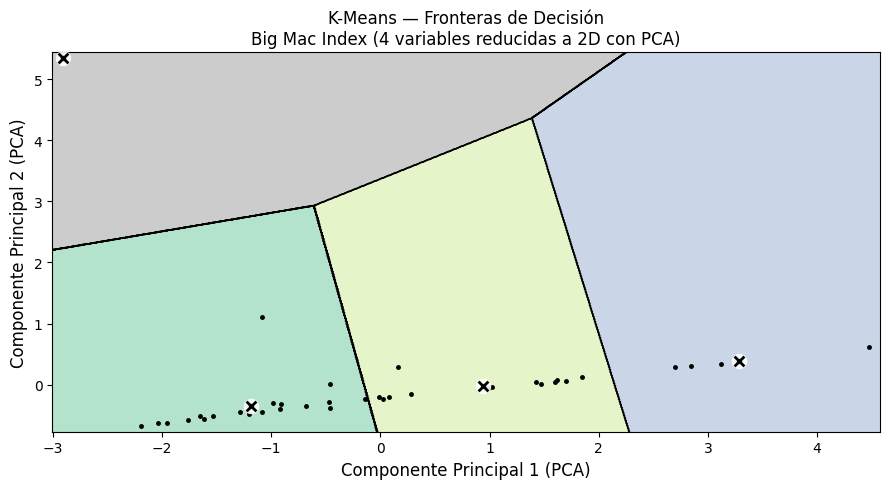

In [8]:
# Entrenamos K-Means sobre los datos reducidos a 2D para graficar fronteras
kmeans_2d = KMeans(n_clusters=k, random_state=42)
kmeans_2d.fit(X_2d)

plt.figure(figsize=(9, 5))
plot_decision_boundaries(kmeans_2d, X_2d)
plt.title('K-Means — Fronteras de Decisión\nBig Mac Index (4 variables reducidas a 2D con PCA)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Predicción de Nuevos Países

In [9]:
# Nuevos datos: [dollar_price, dollar_ex, usd_raw, gdp_dollar]
X_new = np.array([[6.5,  1.0,  0.30, 55000],  # país rico, moneda fuerte
                  [2.0, 18.0, -0.40,  9000],  # país emergente, moneda débil
                  [4.0,  3.5, -0.10, 25000]]) # país intermedio

X_new_scaled = scaler.transform(X_new)
predicciones = kmeans.predict(X_new_scaled)

for i, pred in enumerate(predicciones):
    print(f"País nuevo {i+1} → Cluster {pred}")

País nuevo 1 → Cluster 1
País nuevo 2 → Cluster 0
País nuevo 3 → Cluster 2


## 9. ¿Qué países quedaron en cada cluster?

In [10]:
for i in range(k):
    grupo = df[df['cluster'] == i]
    paises = grupo['name'].tolist()
    avg_price = grupo['dollar_price'].mean()
    avg_gdp = grupo['gdp_dollar'].mean()
    avg_eval = grupo['usd_raw'].mean()
    print(f"\n🌍 Cluster {i}")
    print(f"   Precio Big Mac promedio: ${avg_price:.2f}")
    print(f"   PIB per cápita promedio: ${avg_gdp:,.0f}")
    print(f"   Sobrevaluación promedio: {avg_eval:.2%}")
    print(f"   Países: {', '.join(paises)}")


🌍 Cluster 0
   Precio Big Mac promedio: $2.86
   PIB per cápita promedio: $11,488
   Sobrevaluación promedio: -49.86%
   Países: Argentina, Brazil, Chile, China, Colombia, Egypt, Hong Kong, Hungary, India, Malaysia, Mexico, Pakistan, Peru, Philippines, Poland, Russia, South Africa, Taiwan, Thailand, Turkey

🌍 Cluster 1
   Precio Big Mac promedio: $5.98
   PIB per cápita promedio: $70,484
   Sobrevaluación promedio: 4.73%
   Países: Norway, Sweden, Switzerland, United States

🌍 Cluster 2
   Precio Big Mac promedio: $4.31
   PIB per cápita promedio: $42,768
   Sobrevaluación promedio: -24.46%
   Países: Australia, Britain, Canada, Czech Republic, Denmark, Euro area, Israel, Japan, New Zealand, Saudi Arabia, Singapore, South Korea

🌍 Cluster 3
   Precio Big Mac promedio: $2.36
   PIB per cápita promedio: $3,871
   Sobrevaluación promedio: -58.75%
   Países: Indonesia
